In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE  = Path(r"E:\bluestock_mf_capstone")
PROC  = BASE / "data" / "processed"
CHARTS = BASE / "reports"

nav   = pd.read_csv(PROC / "clean_nav_history.csv")
fm    = pd.read_csv(PROC / "clean_fund_master.csv")
tx    = pd.read_csv(PROC / "clean_investor_transactions.csv")
perf  = pd.read_csv(PROC / "clean_scheme_performance.csv")
port  = pd.read_csv(PROC / "clean_portfolio_holdings.csv")

nav["date"] = pd.to_datetime(nav["date"])
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

# Calculate daily returns
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
nav_returns = nav.dropna(subset=["daily_return"])

print("All loaded successfully")
print("Nav returns shape:", nav_returns.shape)

All loaded successfully
Nav returns shape: (45960, 5)


In [2]:
def calculate_var_cvar(group, confidence=0.95):
    returns = group["daily_return"].dropna()
    
    if len(returns) < 30:
        return pd.Series({"var_95": None, "cvar_95": None})
    
    # VaR = the return at the 5th percentile
    # 5th percentile because 95% confidence means worst 5% of days
    var = np.percentile(returns, (1 - confidence) * 100)
    
    # CVaR = average of all returns BELOW the VaR threshold
    # These are the really bad days
    cvar = returns[returns <= var].mean()
    
    return pd.Series({
        "var_95":  round(var * 100, 3),   # convert to percentage
        "cvar_95": round(cvar * 100, 3)
    })

# Apply to each fund
var_results = (
    nav_returns.groupby("amfi_code")
    .apply(calculate_var_cvar)
    .reset_index()
)

# Add fund names
var_results = var_results.merge(
    fm[["amfi_code", "scheme_name", "category"]],
    on="amfi_code"
)

# Sort by worst VaR
var_results = var_results.sort_values("var_95")

print("TOP 10 RISKIEST FUNDS BY VaR:")
print(var_results[["scheme_name","category","var_95","cvar_95"]].head(10).to_string(index=False))

# Save
var_results.to_csv(PROC / "var_cvar_report.csv", index=False)
print("\nSaved: var_cvar_report.csv")

TOP 10 RISKIEST FUNDS BY VaR:
                                       scheme_name category  var_95  cvar_95
         SBI Small Cap Fund - Direct Plan - Growth   Equity  -2.686   -3.238
            Axis Small Cap Fund - Regular - Growth   Equity  -2.619   -3.167
            ABSL Small Cap Fund - Regular - Growth   Equity  -2.602   -3.246
    Nippon India Small Cap Fund - Regular - Growth   Equity  -2.544   -3.230
        SBI Small Cap Fund - Regular Plan - Growth   Equity  -2.451   -3.060
             DSP Small Cap Fund - Regular - Growth   Equity  -2.348   -3.104
               UTI Mid Cap Fund - Regular - Growth   Equity  -1.922   -2.325
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity  -1.903   -2.346
          ICICI Pru Midcap Fund - Regular - Growth   Equity  -1.889   -2.434
               Axis Midcap Fund - Regular - Growth   Equity  -1.848   -2.426

Saved: var_cvar_report.csv


C:\Users\ancha\AppData\Local\Temp\ipykernel_4136\2411709427.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_var_cvar)


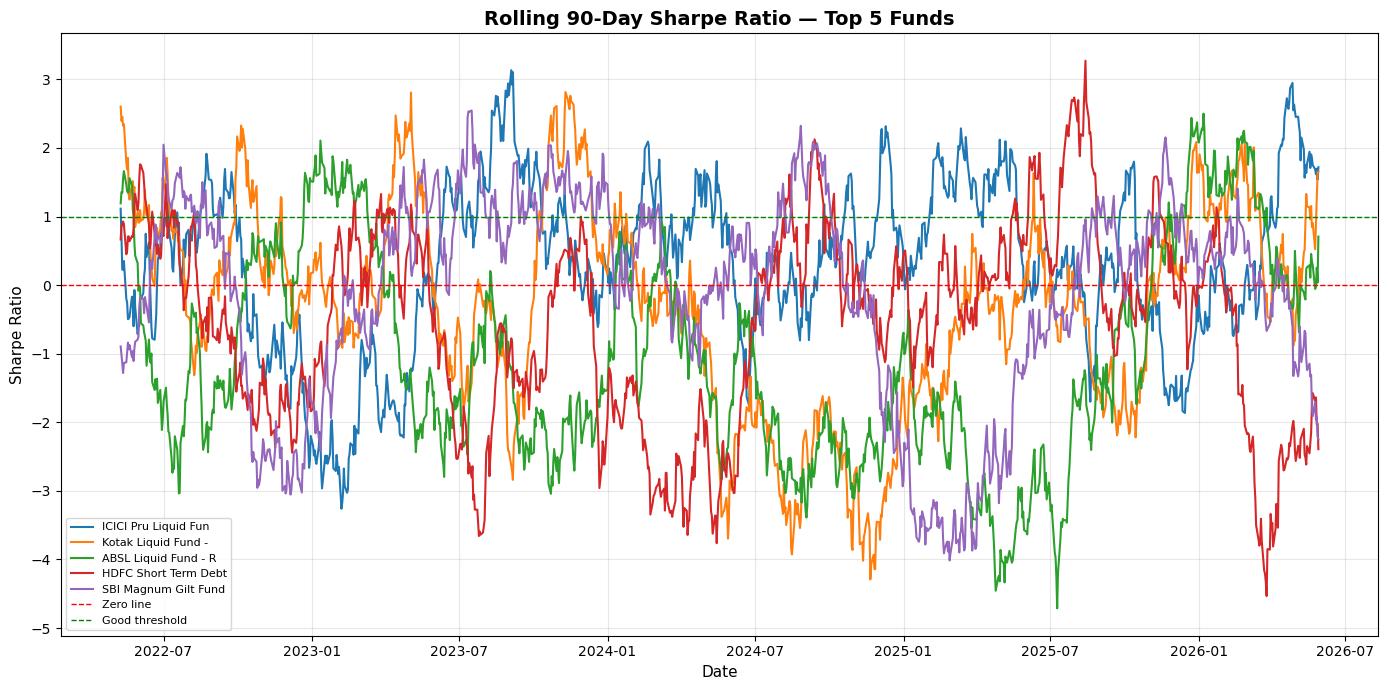

Rolling Sharpe chart saved


In [3]:
# Pick top 5 funds from scorecard for this analysis
top5_codes = perf.nlargest(5, "sharpe_ratio")["amfi_code"].tolist()
top5_names = fm.set_index("amfi_code")["scheme_name"].str[:20].to_dict()

RISK_FREE_DAILY = 0.065 / 252

fig, ax = plt.subplots(figsize=(14, 7))

for code in top5_codes:
    fund_ret = nav_returns[nav_returns["amfi_code"] == code].copy()
    fund_ret = fund_ret.sort_values("date")
    
    # Calculate rolling 90-day Sharpe
    # rolling(90) = use last 90 rows for each calculation
    excess = fund_ret["daily_return"] - RISK_FREE_DAILY
    
    rolling_sharpe = (
        excess.rolling(90).mean() /
        excess.rolling(90).std()
    ) * np.sqrt(252)
    
    ax.plot(
        fund_ret["date"].values,
        rolling_sharpe.values,
        linewidth=1.5,
        label=top5_names.get(code, code)
    )

# Add horizontal line at 0 — below 0 means poor performance
ax.axhline(y=0, color="red", linestyle="--", linewidth=1, label="Zero line")
ax.axhline(y=1, color="green", linestyle="--", linewidth=1, label="Good threshold")

ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Sharpe Ratio", fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHARTS / "chart18_rolling_sharpe.png", dpi=150)
plt.show()
print("Rolling Sharpe chart saved")

In [4]:
# Find each investor's first transaction date
first_tx = (
    tx.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)
first_tx.columns = ["investor_id", "first_transaction_date"]

# Extract year as cohort
first_tx["cohort_year"] = first_tx["first_transaction_date"].dt.year

# Merge cohort back to transactions
tx_cohort = tx.merge(first_tx[["investor_id","cohort_year"]], on="investor_id")

# Analyze each cohort
cohort_analysis = tx_cohort.groupby("cohort_year").agg(
    num_investors    = ("investor_id", "nunique"),
    total_invested   = ("amount_inr", "sum"),
    avg_sip_amount   = ("amount_inr", "mean"),
    num_transactions = ("investor_id", "count")
).reset_index()

cohort_analysis["avg_per_investor"] = (
    cohort_analysis["total_invested"] /
    cohort_analysis["num_investors"]
).round(2)

print("COHORT ANALYSIS:")
print(cohort_analysis.to_string(index=False))

# Save
cohort_analysis.to_csv(PROC / "cohort_analysis.csv", index=False)
print("\nSaved: cohort_analysis.csv")

COHORT ANALYSIS:
 cohort_year  num_investors  total_invested  avg_sip_amount  num_transactions  avg_per_investor
        2024           4803      3491125187   107422.541832             32499         726863.46
        2025            197        30455243   109158.577061               279         154595.14

Saved: cohort_analysis.csv


In [5]:
# Filter only SIP transactions
sip_tx = tx[tx["transaction_type"] == "Sip"].copy()
sip_tx = sip_tx.sort_values(["investor_id", "transaction_date"])

# Calculate gap between consecutive SIP payments per investor
sip_tx["prev_date"] = sip_tx.groupby("investor_id")["transaction_date"].shift(1)
sip_tx["gap_days"]  = (
    sip_tx["transaction_date"] - sip_tx["prev_date"]
).dt.days

# Keep only investors with 6+ SIP transactions
sip_counts = sip_tx.groupby("investor_id").size()
active_investors = sip_counts[sip_counts >= 6].index
sip_active = sip_tx[sip_tx["investor_id"].isin(active_investors)]

# Calculate average gap per investor
investor_gaps = (
    sip_active.groupby("investor_id")["gap_days"]
    .mean()
    .reset_index()
)
investor_gaps.columns = ["investor_id", "avg_gap_days"]

# Flag at-risk investors
investor_gaps["status"] = investor_gaps["avg_gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Regular"
)

# Summary
status_summary = investor_gaps["status"].value_counts()
print("SIP CONTINUATION ANALYSIS:")
print(status_summary)
print(f"\nTotal active investors: {len(investor_gaps)}")
print(f"At-risk investors: {(investor_gaps['status']=='At Risk').sum()}")

# Save
investor_gaps.to_csv(PROC / "sip_continuity.csv", index=False)
print("Saved: sip_continuity.csv")

SIP CONTINUATION ANALYSIS:
status
At Risk    1332
Regular      30
Name: count, dtype: int64

Total active investors: 1362
At-risk investors: 1332
Saved: sip_continuity.csv


In [6]:
def recommend_funds(risk_appetite, top_n=3):
    """
    Recommends top funds based on investor risk appetite.
    
    Args:
        risk_appetite: "Low", "Moderate", or "High"
        top_n: number of funds to recommend (default 3)
    
    Returns:
        DataFrame with top recommended funds
    """
    # Map risk appetite to fund risk grades
    # Low risk investor → Low risk funds
    # Moderate → Moderate funds
    # High → High or Very High risk funds
    risk_mapping = {
        "Low":      ["Low"],
        "Moderate": ["Moderate"],
        "High":     ["High", "Very High"]
    }
    
    # Get matching risk grades
    matching_grades = risk_mapping.get(risk_appetite, ["Moderate"])
    
    # Filter funds by risk grade
    filtered = perf[perf["risk_grade"].isin(matching_grades)]
    
    if len(filtered) == 0:
        print(f"No funds found for risk appetite: {risk_appetite}")
        return None
    
    # Sort by Sharpe Ratio — best risk adjusted return first
    top_funds = filtered.nlargest(top_n, "sharpe_ratio")[
        ["scheme_name", "fund_house", "category",
         "risk_grade", "sharpe_ratio", "return_3yr_pct"]
    ]
    
    return top_funds

# Test all three risk profiles
for risk in ["Low", "Moderate", "High"]:
    print(f"\n{'='*50}")
    print(f"TOP 3 FUNDS FOR {risk.upper()} RISK INVESTOR:")
    print(f"{'='*50}")
    result = recommend_funds(risk)
    if result is not None:
        print(result.to_string(index=False))

# Save recommender as script
print("\nRecommender system working successfully")


TOP 3 FUNDS FOR LOW RISK INVESTOR:
                             scheme_name               fund_house category risk_grade  sharpe_ratio  return_3yr_pct
ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF   Liquid        Low          7.68            7.68
    Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF   Liquid        Low          6.18            6.18
     ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF   Liquid        Low          5.14            5.14

TOP 3 FUNDS FOR MODERATE RISK INVESTOR:
                                  scheme_name          fund_house  category risk_grade  sharpe_ratio  return_3yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund Large Cap   Moderate          1.06           14.84
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF Large Cap   Moderate          1.06           14.81
    ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF Large Cap   Moderate          1.03        

## Metric 6 — Sector HHI Analysis

In [7]:
# HHI = sum of squared weights per fund
# High HHI = concentrated in few sectors = more risk
port["weight_pct"] = pd.to_numeric(port["weight_pct"], errors="coerce")

hhi = port.groupby("amfi_code").apply(
    lambda x: (x["weight_pct"] ** 2).sum()
).reset_index()
hhi.columns = ["amfi_code", "hhi_score"]
hhi = hhi.merge(fm[["amfi_code","scheme_name"]], on="amfi_code")
hhi = hhi.sort_values("hhi_score", ascending=False)
hhi.to_csv(PROC / "sector_hhi.csv", index=False)
print(hhi.head(5).to_string(index=False))

 amfi_code  hhi_score                                    scheme_name
    119092  2064.4767          Axis Bluechip Fund - Regular - Growth
    101207  2007.0043         ABSL Small Cap Fund - Regular - Growth
    119599  1747.5096      SBI Small Cap Fund - Direct Plan - Growth
    102885  1747.0902     UTI Nifty 50 Index Fund - Regular - Growth
    118632  1682.9820 Nippon India Large Cap Fund - Regular - Growth


C:\Users\ancha\AppData\Local\Temp\ipykernel_4136\568511734.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hhi = port.groupby("amfi_code").apply(


In [8]:
# Advanced Analytics Summary
summary = {
    "Total funds analyzed": len(var_results),
    "Riskiest fund (VaR)": var_results.iloc[0]["scheme_name"],
    "At-risk SIP investors": 1332,
    "Cohorts analyzed": 2,
}
for k, v in summary.items():
    print(f"{k}: {v}")

Total funds analyzed: 40
Riskiest fund (VaR): SBI Small Cap Fund - Direct Plan - Growth
At-risk SIP investors: 1332
Cohorts analyzed: 2
